In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import os

import random
# import math  
# from lmfit import Model
# import statsmodels
# import statsmodels.formula.api as smf
from plotnine  import * 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import forestci as fci

# from quantile_forest import RandomForestQuantileRegressor

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression  # Supervised learning model

# %matplotlib inline


In [15]:
# Read in input file

path = '/home/mgabr001/BrainGenix/BrainEmulationChallenge/src/models/autoassociative/NetmorphParOptim'
os.chdir(path)

df1 = pd.read_excel(open('ParameterSpace_700_samples-labeled.xlsx','rb'))    

print(df1.shape)
print(df1.columns)



(700, 9)
Index(['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight', 'usable_conns1',
       'usable_conns2'],
      dtype='str')


In [16]:
# Select Only Needed Columns

columnsA = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight', 'usable_conns1',
       'usable_conns2']


columnsB = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight','usable_conns2']




In [17]:
# sns.pairplot(df1[columnsA], size = 2.5)
# plt.show();

In [18]:
# sns.pairplot(df1[columnsB], size = 2.5)
# plt.show();

In [19]:

# #correlation matrix
# corrmat = df1[columnsA].corr()
# f, ax = plt.subplots(figsize=(9, 6))
# sns.heatmap(corrmat, vmax=.8, square=True);

In [20]:
# # correlation matrix
# f, ax = plt.subplots(figsize=(9, 6))
# k = 10 #number of variables for heatmap
# corrmat = df1[columnsA].corr()
# cols = corrmat.nlargest(k, 'usable_conns1')['usable_conns1'].index
# cm = np.corrcoef(df1[cols].values.T)
# sns.set(font_scale=1.25)
# hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
# plt.show()
# f.savefig('Correlation_Matrix.png')

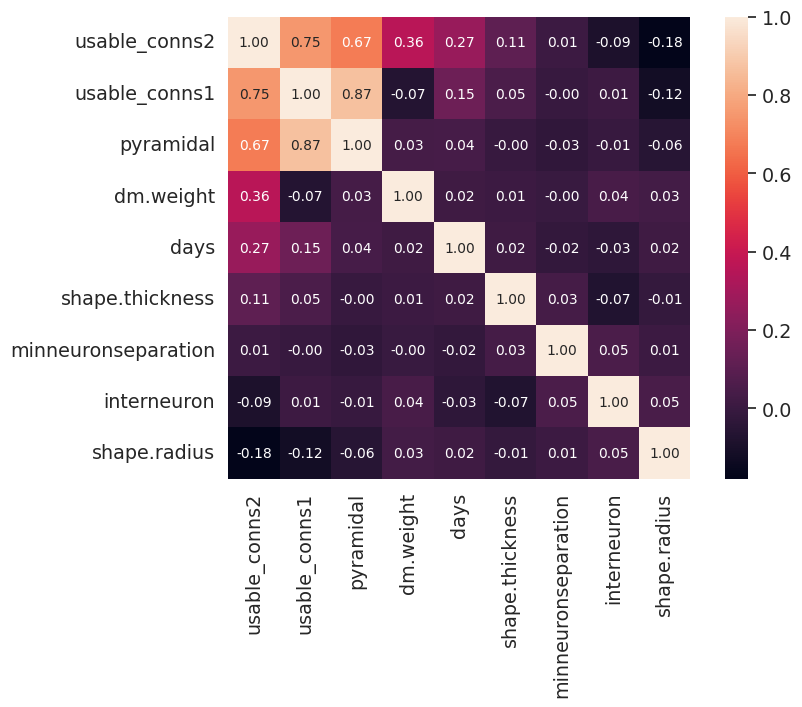

In [21]:

# correlation matrix
f, ax = plt.subplots(figsize=(9, 6))
k = 10 #number of variables for heatmap
corrmat = df1[columnsA].corr()
cols = corrmat.nlargest(k, 'usable_conns2')['usable_conns2'].index
cm = np.corrcoef(df1[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()
f.savefig('Correlation_Matrix.png')

## Create Training and Test datasets: split 80% and 20%

In [22]:
cols = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(df1[cols],df1['usable_conns2'], test_size=0.2, random_state=27)
X_train.shape

(560, 7)

In [24]:
print(X_train.head())
# print(y_train.head()) 

     days  pyramidal  interneuron  minneuronseparation  shape.radius  \
623    22         48           72                   11           160   
372    20         48           40                   14           190   
246    22         64           16                   13           160   
38     21         88          128                   14           200   
562    24        104           32                   15           180   

     shape.thickness  dm.weight  
623               30        0.5  
372               20        0.9  
246               50        0.8  
38                40        0.6  
562               40        0.8  


# Random Forest Regression

In [25]:
clf = RandomForestRegressor(n_estimators=1000, bootstrap = True, oob_score = True, random_state = 27)


# train the model
clf.fit(X_train, y_train)

print('Fit R2 = ', clf.score(X_train, y_train))

# predict on training data
X_train['Pred_usable_conns2'] = clf.predict(X_train)

resid1 = y_train - clf.oob_prediction_


# 95% prediction interval of the training set on individual predictions (95% confidence limits)
lowq = resid1.quantile(0.025)
highq = resid1.quantile(0.975)
print(("Lower Quantile: ", lowq, "   Upper Quantile: ", highq)) 

X_train['Lower'] = (X_train['Pred_usable_conns2']+lowq).clip(0)    # can't have negative numbers
X_train['Upper'] = X_train['Pred_usable_conns2']+highq


# Relative Difference of the Simulated and Predicted usable_conns2 in %.
for item in y_train:
    if item == 0:
        relDiff = 0
    else: 
        relDiff = 100 * abs((item - X_train['Pred_usable_conns2'])/item)


X_train['Relative_percent_diff'] = relDiff


# #### 
# with pd.ExcelWriter("Phase1-_predictions.xlsx") as writer:
#     df1.to_excel(writer, index=False)  



Fit R2 =  0.9748832539328997
('Lower Quantile: ', np.float64(-374.01383372031944), '   Upper Quantile: ', np.float64(480.31521918561816))


In [26]:
X_train.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,Lower,Upper,Relative_percent_diff
623,22,48,72,11,160,30,0.5,205.261,0.000000,685.576219,28.975433
372,20,48,40,14,190,20,0.9,205.771,0.000000,686.086219,28.798962
246,22,64,16,13,160,50,0.8,499.149,125.135166,979.464219,72.715917
38,21,88,128,14,200,40,0.6,363.773,0.000000,844.088219,25.873010
562,24,104,32,15,180,40,0.8,1190.661,816.647166,1670.976219,311.993426


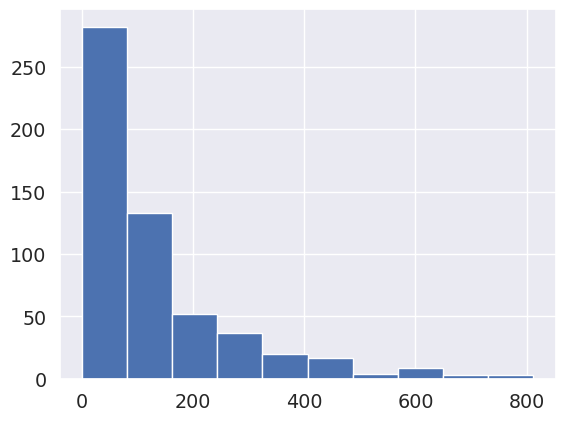

In [27]:
plt.hist(X_train[X_train['Relative_percent_diff']!=0.0]['Relative_percent_diff'])
plt.show() 

In [28]:

V_ij_unbiased = fci.random_forest_error(
  forest=clf, # scikit-learn Forest model fitted on X_train
  X_train_shape = X_train[cols].shape,
  X_test=X_train[cols], # the samples you want to compute the CI
  inbag=None,
  calibrate=True,
  memory_constrained=False,
  memory_limit=None,
  y_output=0 # in case of multioutput model, consider target 0
)


X_train['Pred_Usable_Conns_Err'] = np.sqrt(V_ij_unbiased)

In [29]:
# Predict on Test data
X_test['Pred_usable_conns2'] = clf.predict(X_test)

# Prediction Intervals for the Test data
lowq_test = (X_test['Pred_usable_conns2'] + lowq).clip(0) #cant have negative numbers
highq_test = (X_test['Pred_usable_conns2'] + highq)

print(("Lower Quantile (Test): ", lowq_test, "   Upper Quantile (Test): ", highq_test))

# cover_test = (X_test['Pred_usable_conns2'] >= lowq_test) & (X_test['Pred_usable_conns2'] <= highq_test)
# print(cover_test.mean())


('Lower Quantile (Test): ', 113    1045.527166
596     110.166166
177       0.000000
473     959.286166
434      17.020166
          ...     
37      177.308166
377       0.000000
295     309.790166
420     579.161166
255     333.077166
Name: Pred_usable_conns2, Length: 140, dtype: float64, '   Upper Quantile (Test): ', 113    1899.856219
596     964.495219
177     556.158219
473    1813.615219
434     871.349219
          ...     
37     1031.637219
377     505.670219
295    1164.119219
420    1433.490219
255    1187.406219
Name: Pred_usable_conns2, Length: 140, dtype: float64)


In [30]:
X_train.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,Lower,Upper,Relative_percent_diff,Pred_Usable_Conns_Err
623,22,48,72,11,160,30,0.5,205.261,0.000000,685.576219,28.975433,50.417367
372,20,48,40,14,190,20,0.9,205.771,0.000000,686.086219,28.798962,50.206272
246,22,64,16,13,160,50,0.8,499.149,125.135166,979.464219,72.715917,50.803733
38,21,88,128,14,200,40,0.6,363.773,0.000000,844.088219,25.873010,51.124750
562,24,104,32,15,180,40,0.8,1190.661,816.647166,1670.976219,311.993426,50.825398


In [31]:
X_test.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2
113,23,128,104,12,140,30,0.6,1419.541
596,22,64,32,14,140,50,0.6,484.180
177,25,24,40,10,180,50,0.7,75.843
473,20,128,112,11,150,30,0.7,1333.300
434,24,48,32,11,150,40,0.9,391.034


In [32]:

# Calculate the variance
# Notes
# The calculation of error is based on the infinitesimal jackknife variance, as described in [Wager2014] 
# and is a Python implementation of the R code provided at: https://github.com/swager/randomForestCI
# Wager2014
#    S. Wager, T. Hastie, B. Efron. “Confidence Intervals for Random Forests: 
# The Jackknife and the Infinitesimal Jackknife”, Journal of Machine Learning Research vol. 15, pp. 1625-1651, 2014.

# The basic idea of the jackknife is to omit one observation and recompute the estimate using the remaining observations. 
# This is done for each observation, and the results are then combined to produce a variance estimate or bias correction.


V_ij_unbiased = fci.random_forest_error(
  forest=clf, # scikit-learn Forest model fitted on X_train
  X_train_shape = X_train[cols].shape,
  X_test=X_test[cols], # the samples you want to compute the CI
  inbag=None,
  calibrate=True,
  memory_constrained=False,
  memory_limit=None,
  y_output=0 # in case of multioutput model, consider target 0
)


X_test['Pred_Usable_Conns_Err'] = np.sqrt(V_ij_unbiased)



In [33]:
print(" Mean Error +\- Std of Errors: ", X_test['Pred_Usable_Conns_Err'].mean() ,"+\-", X_test['Pred_Usable_Conns_Err'].std())

 Mean Error +\- Std of Errors:  76.90495851451631 +\- 51.701654278714855


### Combine with labels column before sorting.  Needed for overlaying plots.

In [34]:
X_train['usable_conns2'] = y_train
X_test['usable_conns2'] = y_test


In [35]:
X_train.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,Lower,Upper,Relative_percent_diff,Pred_Usable_Conns_Err,usable_conns2
623,22,48,72,11,160,30,0.5,205.261,0.000000,685.576219,28.975433,50.417367,193
372,20,48,40,14,190,20,0.9,205.771,0.000000,686.086219,28.798962,50.206272,208
246,22,64,16,13,160,50,0.8,499.149,125.135166,979.464219,72.715917,50.803733,521
38,21,88,128,14,200,40,0.6,363.773,0.000000,844.088219,25.873010,51.124750,311
562,24,104,32,15,180,40,0.8,1190.661,816.647166,1670.976219,311.993426,50.825398,1218


In [36]:
X_test.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,Pred_Usable_Conns_Err,usable_conns2
113,23,128,104,12,140,30,0.6,1419.541,82.755278,2103
596,22,64,32,14,140,50,0.6,484.180,56.487059,475
177,25,24,40,10,180,50,0.7,75.843,55.763492,86
473,20,128,112,11,150,30,0.7,1333.300,67.571614,803
434,24,48,32,11,150,40,0.9,391.034,56.324669,325


In [37]:
X_train.sort_values(by='Pred_usable_conns2', ascending=False, inplace = True)
X_train.reset_index(drop=True, inplace=True)


X_test.sort_values(by='Pred_usable_conns2', ascending=False, inplace = True)
X_test.reset_index(drop=True, inplace=True)


In [38]:
# X_train[X_train['usable_conns2'] > 2800].head()

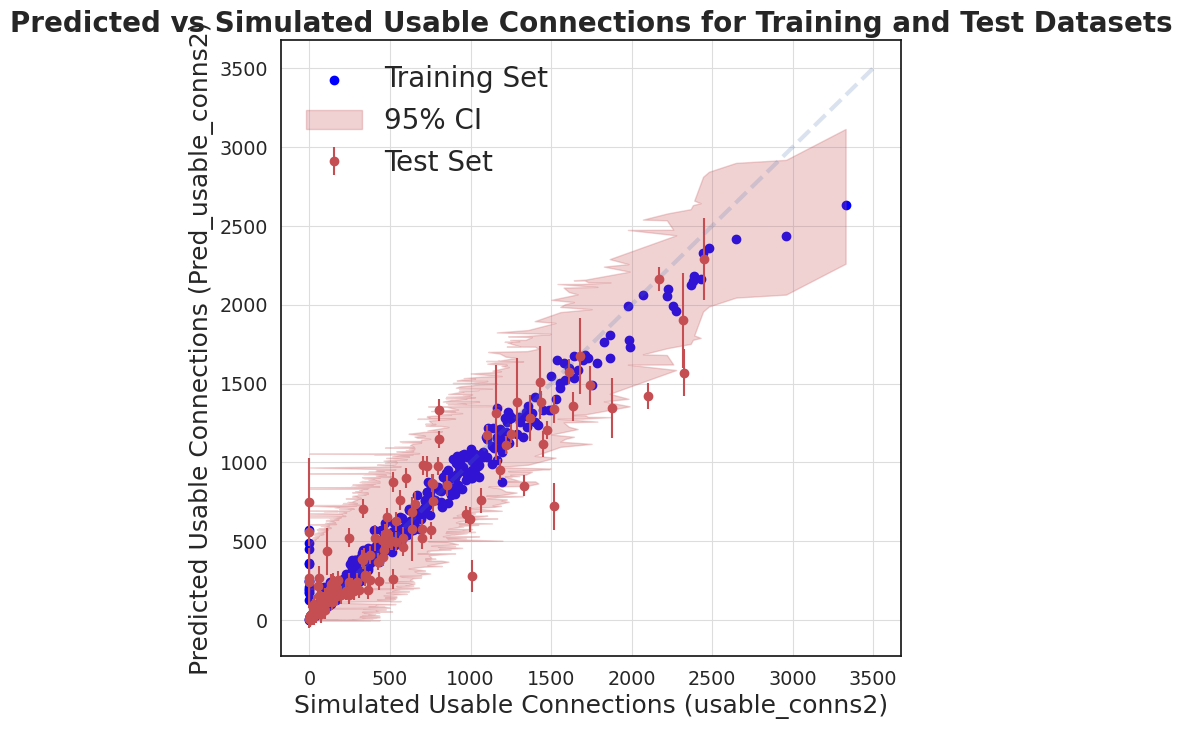

In [39]:
f, ax = plt.subplots(figsize=(8, 8))

plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2'], color ='blue', label = 'Training Set')

plt.errorbar(X_test['usable_conns2'],  X_test['Pred_usable_conns2'], yerr = X_test['Pred_Usable_Conns_Err'], fmt='o',color ='r', label = 'Test Set')

# plt.fill_between(X_train['usable_conns2'], X_train['Pred_usable_conns2']-1.96*X_train['Pred_Usable_Conns_Err'], X_train['Pred_usable_conns2'] + 1.96*X_train['Pred_Usable_Conns_Err'], color='r', alpha=0.25, label = '95% CI')
# plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2']-1.96*X_train['Pred_Usable_Conns_Err'], color ='cyan', marker='+' )
# plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2']+1.96*X_train['Pred_Usable_Conns_Err'], color ='green', marker='+' )

plt.fill_between(X_train['usable_conns2'], X_train['Lower'], X_train['Upper'], color='r', alpha=0.25, label = '95% CI')
# plt.scatter(X_train['usable_conns2'], X_train['Lower'], color ='cyan', marker='+' )
# plt.scatter(X_train['usable_conns2'], X_train['Upper'], color ='green', marker='+' )

plt.plot(np.linspace(0,3500,1000), np.linspace(0,3500, 1000), 'b--', linewidth=3, alpha= 0.2)

plt.gca().set_facecolor('xkcd:white')
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)


ax.spines['bottom'].set_color('k')
ax.spines['top'].set_color('k')
ax.spines['left'].set_color('k')
ax.spines['right'].set_color('k')

# plt.xlim([0,3500])
# plt.ylim([0,3500])
plt.rc('font', size=18) 
plt.rc('font', size=18) 

plt.title('Predicted vs Simulated Usable Connections for Training and Test Datasets',size = 20, fontweight="bold")
plt.xlabel('Simulated Usable Connections (usable_conns2)',size =18)
plt.ylabel('Predicted Usable Connections (Pred_usable_conns2)',size = 18)
plt.legend(loc='upper left', prop={'size': 20},framealpha=0.)
plt.show()
# f.savefig('Pred_vs_Sim_UsableConns.png')

In [40]:
X_test[(X_test['usable_conns2'] == 0) & (X_test['Pred_usable_conns2'] > 0) ].head()   

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,Pred_Usable_Conns_Err,usable_conns2
36,21,128,72,11,100,20,0.5,747.234,278.988445,0
48,21,96,96,11,100,20,0.9,558.691,78.379115,0
73,21,120,80,10,100,30,0.7,267.558,189.462002,0
81,22,112,80,10,100,20,0.1,239.883,59.215234,0
139,21,24,56,12,160,20,0.1,4.469,55.723674,0


In [41]:
X_train[(X_train['usable_conns2'] == 0) & (X_train['Pred_usable_conns2'] > 0) ]

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,Lower,Upper,Relative_percent_diff,Pred_Usable_Conns_Err,usable_conns2
187,25,120,16,10,100,20,0.8,574.909,200.895166,1055.224219,98.930450,546.045860,0
222,23,128,64,10,100,30,0.9,487.819,113.805166,968.134219,68.795502,485.862844,0
233,25,120,112,10,110,20,0.6,450.224,76.210166,930.539219,55.786851,499.873138,0
275,24,80,112,13,100,20,1.0,361.832,0.000000,842.147219,25.201384,358.718016,0
278,25,112,96,12,100,20,0.6,354.324,0.000000,834.639219,22.603460,404.572602,0
326,21,104,112,15,100,30,0.7,249.255,0.000000,729.570219,13.752595,243.707766,0
331,23,112,56,14,100,20,0.9,246.801,0.000000,727.116219,14.601730,281.782457,0
345,21,120,72,14,100,30,0.8,213.383,0.000000,693.698219,26.165052,259.901405,0
356,21,80,128,13,110,20,0.9,196.004,0.000000,676.319219,32.178547,180.743918,0
358,20,112,40,13,100,20,0.5,189.767,0.000000,670.082219,34.336678,210.381645,0


In [42]:
cols

['days',
 'pyramidal',
 'interneuron',
 'minneuronseparation',
 'shape.radius',
 'shape.thickness',
 'dm.weight']

## Principal Component Analysis (PCA) On Training dataset

In [43]:

# Fit the PCA object and use PCA Scree plot to determine the number of Principal components to retain
X_train_X7 = X_train[cols]
pca_7 = PCA(n_components=7).fit(X_train_X7)
var = pca_7.explained_variance_ratio_ # Variance ratio per component.



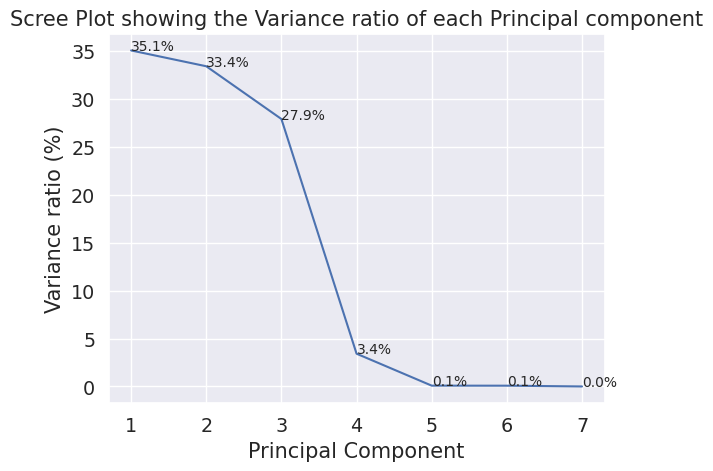

In [48]:

# Create a more advanced scree plot to visualize the explained variance
fig, ax = plt.subplots()
ax.plot(range(1, len(var) + 1), var*100)

# Label the data points to xx.x%
for n, v in enumerate(var):
    ax.text(n+1, v*100, str(round(v*100, 1))+"%", fontsize=10)

# # Label the data points to xx.x%
# for n, v in enumerate(var):
#     ax.text(n+1, v*100, str(round(v*100, 1))+"%", fontsize=10)

# Add title, axis labels, and background grid
plt.title('Scree Plot showing the Variance ratio of each Principal component')
plt.xlabel('Principal Component')
plt.ylabel('Variance ratio (%)')
plt.xticks(range(1, len(var) + 1))
plt.grid(True)
plt.show()

In [49]:

# Use PCA to transform a DataFrame of feature-variables to PCA loadings
# Lets look at PCA for the purpose of dimensional reductions.

pca_7_trans_X_train = pca_7.transform(X_train_X7) # PCA(n_components=7).fit_transform(pred_grid_X7)
X_train_X7_comp = pd.DataFrame(data = pca_7_trans_X_train , columns = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7"])
DF_X4=X_train_X7_comp[["PC1", "PC2", "PC3", "PC4"]]
DF_X4Y = pd.concat([DF_X4, X_train['usable_conns2'] ], axis = 1)


In [50]:
DF_X4Y.head()

,PC1,PC2,PC3,PC4,usable_conns2
0,-33.005752,47.415420,-26.094899,-5.179697,3329
1,0.956571,66.291363,-37.159608,6.309252,2959
2,-64.306254,27.184671,-5.221009,13.239514,2648
3,-55.365151,36.128794,3.027618,13.498360,2480
4,-66.244329,30.620022,17.412421,12.822163,2444


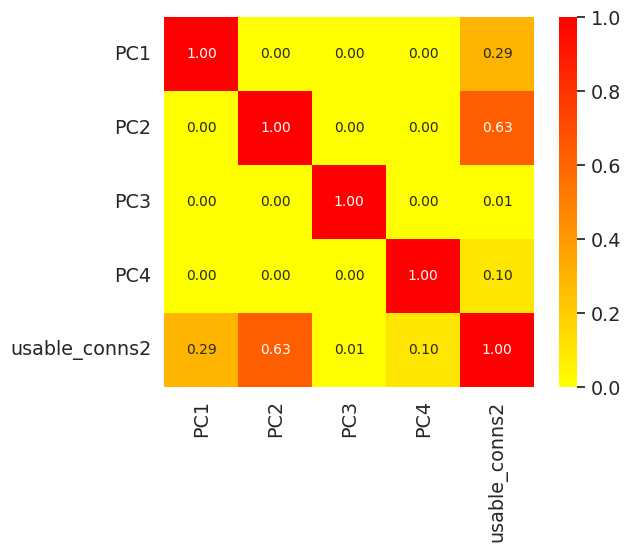

In [51]:

# Make a correlation matrix and heatmap of the 5 selected principal components and the target feature-variable.
corr_matrix = DF_X4Y.corr()
sns.heatmap(abs(corr_matrix), cmap=plt.cm.autumn_r,  cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10})
plt.show()

In [52]:
clms = ["PC1", "PC2", "PC3", "PC4"]

In [53]:
clf1 = RandomForestRegressor(n_estimators=1000, bootstrap = True, oob_score = True, random_state = 27)

# Use a basic regression model to display a simple way of using Principal components loadings as
# regression variables for indices purposes.
clf1.fit(DF_X4Y[["PC1", "PC2", "PC3", "PC4"]], DF_X4Y["usable_conns2"])

DF_X4Y["Pred_usable_conns2_PCA"] = clf1.predict(DF_X4Y[["PC1", "PC2", "PC3", "PC4"]])

DF_X4Y["Residual"] = DF_X4Y["usable_conns2"] - DF_X4Y["Pred_usable_conns2_PCA"]
# DF_X4Y["Residual"] = DF_X4Y["usable_conns2"] - clf1.oob_prediction_


# 95% prediction interval of the training set on individual predictions (95% confidence limits)
lowq = DF_X4Y["Residual"].quantile(0.025)
highq = DF_X4Y["Residual"].quantile(0.975)
print(("Lower Quantile: ", lowq, "   Upper Quantile: ", highq)) 

DF_X4Y['Lower'] = (DF_X4Y['Pred_usable_conns2_PCA']+lowq).clip(0)    # can't have negative numbers
DF_X4Y['Upper'] = DF_X4Y['Pred_usable_conns2_PCA']+highq



('Lower Quantile: ', np.float64(-304.15815), '   Upper Quantile: ', np.float64(323.6364999999997))


In [54]:
DF_X4Y.head()

,PC1,PC2,PC3,PC4,usable_conns2,Pred_usable_conns2_PCA,Residual,Lower,Upper
0,-33.005752,47.415420,-26.094899,-5.179697,3329,2535.959,793.041,2231.80085,2859.5955
1,0.956571,66.291363,-37.159608,6.309252,2959,2274.907,684.093,1970.74885,2598.5435
2,-64.306254,27.184671,-5.221009,13.239514,2648,2290.672,357.328,1986.51385,2614.3085
3,-55.365151,36.128794,3.027618,13.498360,2480,2244.848,235.152,1940.68985,2568.4845
4,-66.244329,30.620022,17.412421,12.822163,2444,2220.584,223.416,1916.42585,2544.2205


In [55]:
clms=["PC1", "PC2", "PC3", "PC4"]

In [56]:

V_ij_unbiased = fci.random_forest_error(
  forest=clf1, # scikit-learn Forest model fitted on X_train
  X_train_shape = DF_X4Y[clms].shape,
  X_test=DF_X4Y[clms], # the samples you want to compute the CI
  inbag=None,
  calibrate=True,
  memory_constrained=False,
  memory_limit=None,
  y_output=0 # in case of multioutput model, consider target 0
)


DF_X4Y['Pred_Usable_Conns_Err'] = np.sqrt(V_ij_unbiased)

#### Create Test dataset and transform into PCA coordinates

In [57]:
X_test_X7 = X_test[cols]

In [58]:
pca_7_trans_X_test = pca_7.transform(X_test_X7) # PCA(n_components=7).fit_transform(....)
X_test_X7_comp = pd.DataFrame(data = pca_7_trans_X_test , columns = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7"])
DF_X4_test = X_test_X7_comp[["PC1", "PC2", "PC3", "PC4"]]
DF_X4Y_test = pd.concat([DF_X4_test, X_test['usable_conns2'] ], axis = 1)

In [59]:
DF_X4Y_test.head()

,PC1,PC2,PC3,PC4,usable_conns2
0,-63.996457,27.314248,-5.395908,3.252439,2449
1,22.504059,64.729486,-2.557763,6.349140,2171
2,-76.677303,33.629360,-10.624094,3.030505,2320
3,-63.686831,27.443707,-5.570885,-6.734557,1680
4,-38.884312,47.476221,8.546620,4.049498,1609


In [64]:
# Predict on Test data
DF_X4Y_test['Pred_usable_conns2_PCA'] = clf1.predict(DF_X4Y_test[["PC1", "PC2", "PC3", "PC4"]])

# Prediction Intervals for the Test data
lowq_test = (DF_X4Y_test['Pred_usable_conns2_PCA'] + lowq).clip(0) #cant have negative numbers
highq_test = (DF_X4Y_test['Pred_usable_conns2_PCA'] + highq)

print(("Lower Quantile (Test): ", lowq_test, "   Upper Quantile (Test): ", highq_test))



('Lower Quantile (Test): ', 0      1436.98985
1      1557.91985
2       570.03885
3       856.49585
4      1066.44185
          ...    
135       0.00000
136       0.00000
137       0.00000
138       0.00000
139       0.00000
Name: Pred_usable_conns2_PCA, Length: 140, dtype: float64, '   Upper Quantile (Test): ', 0      2064.7845
1      2185.7145
2      1197.8335
3      1484.2905
4      1694.2365
         ...    
135     369.9065
136     513.6435
137     398.9955
138     380.1735
139     361.2385
Name: Pred_usable_conns2_PCA, Length: 140, dtype: float64)


In [65]:
DF_X4Y_test.head()

,PC1,PC2,PC3,PC4,usable_conns2,Pred_Usable_Conns_Err,Pred_usable_conns2_PCA
0,-63.996457,27.314248,-5.395908,3.252439,2449,351.664212,1741.148
1,22.504059,64.729486,-2.557763,6.349140,2171,192.755039,1862.078
2,-76.677303,33.629360,-10.624094,3.030505,2320,615.698293,874.197
3,-63.686831,27.443707,-5.570885,-6.734557,1680,329.309718,1160.654
4,-38.884312,47.476221,8.546620,4.049498,1609,175.589771,1370.600


In [66]:

# Calculate the variance
# Notes
# The calculation of error is based on the infinitesimal jackknife variance, as described in [Wager2014] 
# and is a Python implementation of the R code provided at: https://github.com/swager/randomForestCI
# Wager2014
#    S. Wager, T. Hastie, B. Efron. “Confidence Intervals for Random Forests: 
# The Jackknife and the Infinitesimal Jackknife”, Journal of Machine Learning Research vol. 15, pp. 1625-1651, 2014.

# The basic idea of the jackknife is to omit one observation and recompute the estimate using the remaining observations. 
# This is done for each observation, and the results are then combined to produce a variance estimate or bias correction.


V_ij_unbiased = fci.random_forest_error(
  forest=clf1, # scikit-learn Forest model fitted on X_train
  X_train_shape = DF_X4Y[clms].shape,
  X_test=DF_X4Y_test[clms], # the samples you want to compute the CI
  inbag=None,
  calibrate=True,
  memory_constrained=False,
  memory_limit=None,
  y_output=0 # in case of multioutput model, consider target 0
)


DF_X4Y_test['Pred_Usable_Conns_Err'] = np.sqrt(V_ij_unbiased)



In [67]:
print(" Mean Error +\- Std of Errors: ", X_test['Pred_Usable_Conns_Err'].mean() ,"+\-", X_test['Pred_Usable_Conns_Err'].std())

 Mean Error +\- Std of Errors:  76.90495851451631 +\- 51.701654278714855


In [68]:
DF_X4Y.head()

,PC1,PC2,PC3,PC4,usable_conns2,Pred_usable_conns2_PCA,Residual,Lower,Upper,Pred_Usable_Conns_Err
0,-33.005752,47.415420,-26.094899,-5.179697,3329,2535.959,793.041,2231.80085,2859.5955,832.641588
1,0.956571,66.291363,-37.159608,6.309252,2959,2274.907,684.093,1970.74885,2598.5435,756.858559
2,-64.306254,27.184671,-5.221009,13.239514,2648,2290.672,357.328,1986.51385,2614.3085,379.379512
3,-55.365151,36.128794,3.027618,13.498360,2480,2244.848,235.152,1940.68985,2568.4845,253.167086
4,-66.244329,30.620022,17.412421,12.822163,2444,2220.584,223.416,1916.42585,2544.2205,232.069767


In [69]:
DF_X4Y_test.head()

,PC1,PC2,PC3,PC4,usable_conns2,Pred_Usable_Conns_Err,Pred_usable_conns2_PCA
0,-63.996457,27.314248,-5.395908,3.252439,2449,352.147707,1741.148
1,22.504059,64.729486,-2.557763,6.349140,2171,220.626953,1862.078
2,-76.677303,33.629360,-10.624094,3.030505,2320,615.698293,874.197
3,-63.686831,27.443707,-5.570885,-6.734557,1680,331.349629,1160.654
4,-38.884312,47.476221,8.546620,4.049498,1609,203.736434,1370.600


In [70]:
DF_X4Y.sort_values(by='Pred_usable_conns2_PCA', ascending=False, inplace = True)
DF_X4Y.reset_index(drop=True, inplace=True)


DF_X4Y_test.sort_values(by='Pred_usable_conns2_PCA', ascending=False, inplace = True)
DF_X4Y_test.reset_index(drop=True, inplace=True)


In [71]:
# X_train[X_train['usable_conns2'] > 2800].head()

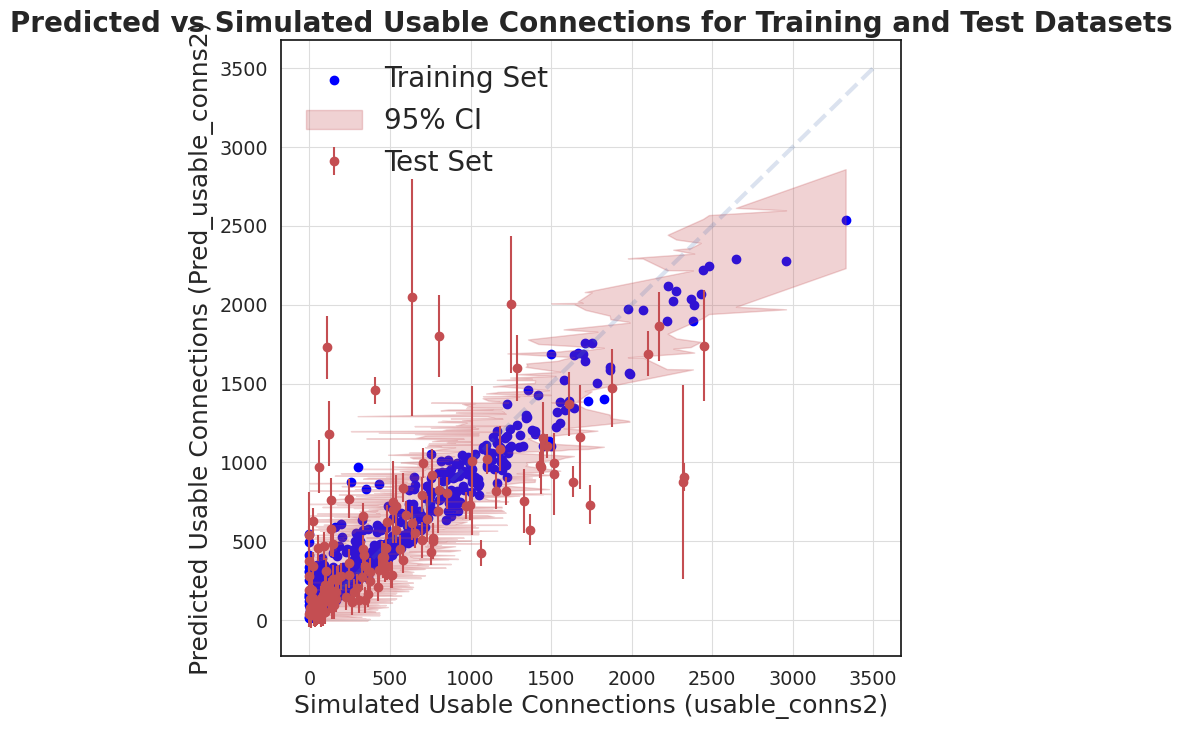

In [76]:
f, ax = plt.subplots(figsize=(8, 8))

plt.scatter(DF_X4Y['usable_conns2'], DF_X4Y['Pred_usable_conns2_PCA'], color ='blue', label = 'Training Set')

plt.errorbar(DF_X4Y_test['usable_conns2'],  DF_X4Y_test['Pred_usable_conns2_PCA'], yerr = DF_X4Y_test['Pred_Usable_Conns_Err'], fmt='o',color ='r', label = 'Test Set')

# plt.fill_between(DF_X4Y['usable_conns2'], DF_X4Y['Pred_usable_conns2_PCA']-DF_X4Y['Pred_Usable_Conns_Err'], DF_X4Y['Pred_usable_conns2_PCA']+DF_X4Y['Pred_Usable_Conns_Err'], color='r', alpha=0.25, label = '95% CI')
plt.fill_between(DF_X4Y['usable_conns2'], DF_X4Y['Lower'], DF_X4Y['Upper'], color='r', alpha=0.25, label = '95% CI')
# plt.scatter(DF_X4Y['usable_conns2'], DF_X4Y['Lower'], color ='cyan', marker='+' )
# plt.scatter(DF_X4Y['usable_conns2'], DF_X4Y['Upper'], color ='green', marker='+' )

plt.plot(np.linspace(0,3500,1000), np.linspace(0,3500, 1000), 'b--', linewidth=3, alpha= 0.2)

plt.gca().set_facecolor('xkcd:white')
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)


ax.spines['bottom'].set_color('k')
ax.spines['top'].set_color('k')
ax.spines['left'].set_color('k')
ax.spines['right'].set_color('k')

# plt.xlim([0,3500])
# plt.ylim([0,3500])
plt.rc('font', size=18) 
plt.rc('font', size=18) 

plt.title('Predicted vs Simulated Usable Connections for Training and Test Datasets',size = 20, fontweight="bold")
plt.xlabel('Simulated Usable Connections (usable_conns2)',size =18)
plt.ylabel('Predicted Usable Connections (Pred_usable_conns2)',size = 18)
plt.legend(loc='upper left', prop={'size': 20},framealpha=0.)
plt.show()
# f.savefig('Pred_vs_Sim_UsableConns.png')

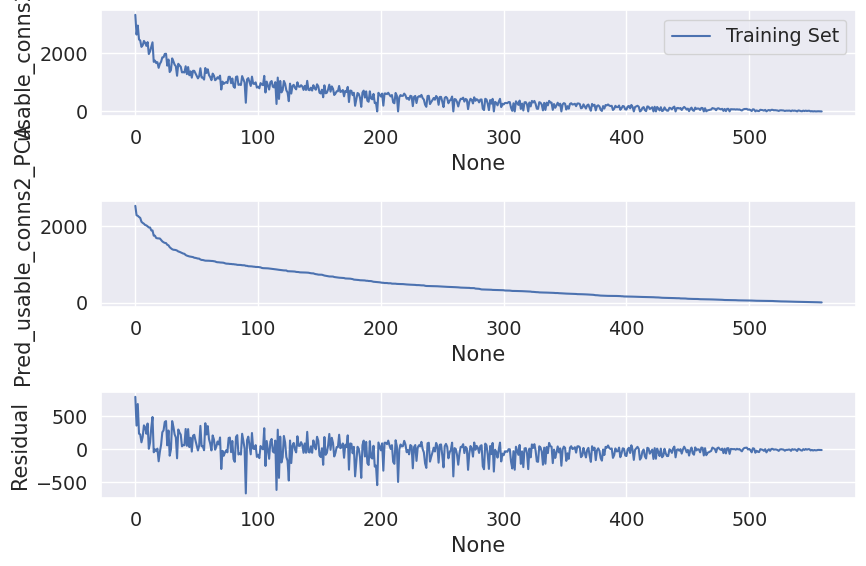

In [79]:

# Make two basic indices graphs
# Plot the Target feature-variable vs. the principal components
# fig, ((ax1), (ax2), (ax3), (ax4), (ax5)) = plt.subplots(5,1)
fig, ((ax1), (ax2), (ax3)) = plt.subplots(figsize=(9, 6), nrows=3, ncols=1)
sns.lineplot(data=DF_X4Y, x=DF_X4Y.index, y="usable_conns2", ax=ax1, label = 'Training Set')
sns.lineplot(data=DF_X4Y, x=DF_X4Y.index, y="Pred_usable_conns2_PCA", ax=ax2)
sns.lineplot(data=DF_X4Y, x=DF_X4Y.index, y="Residual", ax=ax3)


fig.tight_layout()
plt.show()


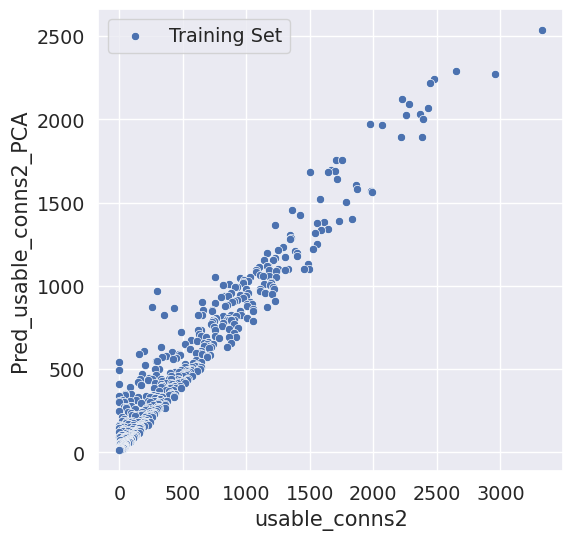

In [ ]:
fig, ax1 = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=DF_X4Y, x="usable_conns2", y="Pred_usable_conns2_PCA", ax=ax1, label = 'Training Set')
ax1.set_xlim(0,3500)
ax1.set_ylim(0, 3500)
plt.show()


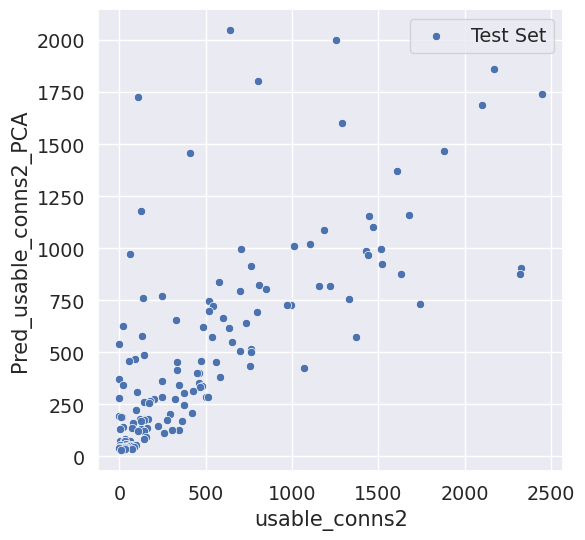

In [ ]:
fig, ax1 = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=DF_X4Y_test, x="usable_conns2", y="Pred_usable_conns2_PCA", ax=ax1, label = 'Test Set')
ax1.set_xlim(0,3500)
ax1.set_ylim(0, 3500)
plt.show()


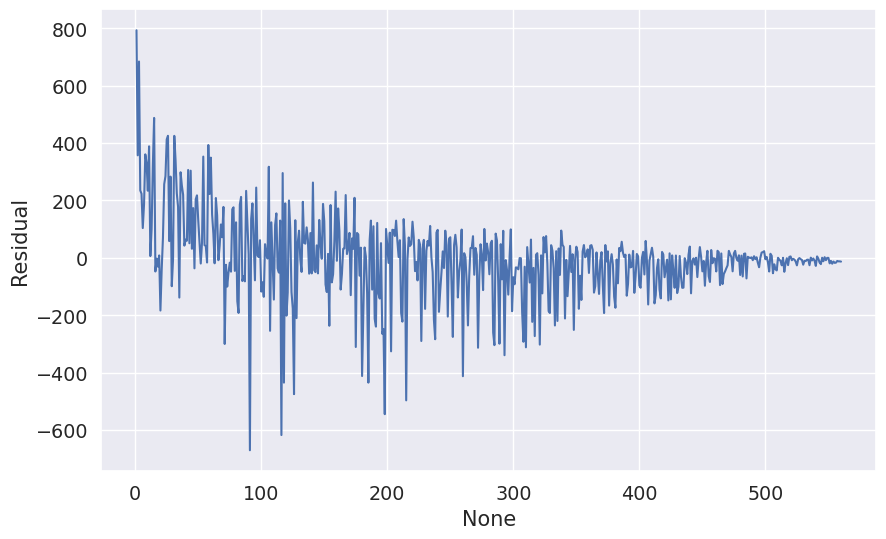

In [83]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=DF_X4Y, x=DF_X4Y.index+1, y="Residual", ax=ax)
plt.show()

## Create Full Grid: Method 1

In [84]:
# Generate the FULL parameter Space

days = np.arange(20, 26, 1)                         # 6
pyramidal= np.arange(16, 136, 8)                    # 15        
interneuron = np.arange(16, 136, 8)                 # 15
minneuronseparation = np.arange(10, 16, 1)          # 6
shape_radius = np.arange(100, 210, 10)              # 11  
shape_thickness = np.arange(20, 60, 10)             # 4
dm_weight = np.arange(0.1, 1.1, 0.1)                # 10

ldays = len(days)
lpyramidal = len(pyramidal)
linterneuron = len(interneuron)     
lminneuronseparation = len(minneuronseparation)
lshape_radius = len(shape_radius)
lshape_thickness = len(shape_thickness)
ldm_weight = len(dm_weight) 




In [ ]:
# N = ldays * lpyramidal * linterneuron * lminneuronseparation * lshape_radius * lshape_thickness * ldm_weight
# print("N = ", N)
# #full grid
# arr=[(N,9)]

# for i in range(ldays):
#     for j in range(lpyramidal):
#         for k in range(linterneuron):
#             for l in range(lminneuronseparation):
#                 for m in range(lshape_radius):
#                     for n in range(lshape_thickness):
#                        for ii in range(ldm_weight):
                         
#                                 arr.append([ days[i], pyramidal[j], interneuron[k], minneuronseparation[l], shape_radius[m], shape_thickness[n], dm_weight[ii] ])
#                                 #######  When created this way, the first row of the arr is the total # of rows and needs to be dropped when creating the prediction grid.
#                                 #print([ days[i], pyramidal[j], interneuron[k], minneuronseparation[l], shape_radius[m], shape_thickness[n], dm_weight[ii]])



## Create Full Grid: Method 2

In [98]:
N = ldays * lpyramidal * linterneuron * lminneuronseparation * lshape_radius * lshape_thickness * ldm_weight
print("N = ", N)
#full grid
arr=[(N,9)]

#######  When created this way, the first row should not be dropped when creating the prediction grid.

arr = [[ days[i], pyramidal[j], interneuron[k], minneuronseparation[l], shape_radius[m], shape_thickness[n], dm_weight[ii] ] \
    for i in range(ldays) \
    for j in range(lpyramidal) \
    for k in range(linterneuron) \
    for l in range(lminneuronseparation) \
    for m in range(lshape_radius) \
    for n in range(lshape_thickness) \
    for ii in range(ldm_weight)]
  

N =  3564000


In [99]:
print("Length of arr:", len(arr))

Length of arr: 3564000


In [100]:
print(arr[:1 :])

[[np.int64(20), np.int64(16), np.int64(16), np.int64(10), np.int64(100), np.int64(20), np.float64(0.1)]]


# Create a prediction array for the entire parameter space

In [101]:
# Create a prediction array for the entire parameter space

cols = ['days', 
        'pyramidal', 
        'interneuron', 
        'minneuronseparation',
        'shape.radius', 
        'shape.thickness', 
        'dm.weight'
        ]

pred_grid = pd.DataFrame(data = arr, columns = cols)

# pred_grid.drop_duplicates(keep='first', inplace=True)
# pred_grid = pred_grid.iloc[1:]  # drop the first row. 1st row is the total # rows and columns 
pred_grid.shape


(3564000, 7)

In [102]:
pred_grid.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight
0,20,16,16,10,100,20,0.1
1,20,16,16,10,100,20,0.2
2,20,16,16,10,100,20,0.3
3,20,16,16,10,100,20,0.4
4,20,16,16,10,100,20,0.5


# Predict Usable Connections for the entire parameter space using Best FIT model.

In [ ]:
# Make predictions using the RF regressor without PCA on the entire parameter space grid.


# pred_grid['Pred_usable_conns2'] = clf.predict(pred_grid[cols])
# pred_grid['Lower'] = (pred_grid['Pred_usable_conns2']+lowq).clip(0)
# pred_grid['Upper'] = pred_grid ['Pred_usable_conns2']+highq

In [103]:
# Transform the entire parameter space grid using PCA to make predictions using the RF regressor with PCA on the entire parameter space grid.   
# pred_grid_X7 = pred_grid[cols]

pca_7_pred_grid = pca_7.transform(pred_grid) # PCA(n_components=7).fit_transform(pred_grid_X7)
pred_grid_X7_comp = pd.DataFrame(data = pca_7_pred_grid , columns = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7"])
pred_grid_X4 = pred_grid_X7_comp[["PC1", "PC2", "PC3", "PC4"]]
print(pred_grid_X4.head())

         PC1        PC2        PC3        PC4
0 -55.316938 -64.346059 -39.899419 -17.106297
1 -55.316895 -64.346029 -39.899400 -17.106316
2 -55.316853 -64.345999 -39.899381 -17.106336
3 -55.316810 -64.345969 -39.899362 -17.106355
4 -55.316767 -64.345939 -39.899343 -17.106375


In [104]:
# Make predictions using the RF regressor with PCA on the entire parameter space grid. 
clms=["PC1", "PC2", "PC3", "PC4"]

pred_grid_X4['Pred_usable_conns2'] = clf1.predict(pred_grid_X4[clms])
pred_grid_X4['Lower'] = (pred_grid_X4['Pred_usable_conns2']+lowq).clip(0)
pred_grid_X4['Upper'] = pred_grid_X4['Pred_usable_conns2']+highq


In [106]:
pred_grid_X4.head()

,PC1,PC2,PC3,PC4,Pred_usable_conns2,Lower,Upper
0,-55.316938,-64.346059,-39.899419,-17.106297,133.982,0.0,457.6185
1,-55.316895,-64.346029,-39.899400,-17.106316,133.982,0.0,457.6185
2,-55.316853,-64.345999,-39.899381,-17.106336,133.982,0.0,457.6185
3,-55.316810,-64.345969,-39.899362,-17.106355,133.982,0.0,457.6185
4,-55.316767,-64.345939,-39.899343,-17.106375,133.982,0.0,457.6185


In [ ]:

# # Calculate the variance
# # Notes
# # The calculation of error is based on the infinitesimal jackknife variance, as described in [Wager2014] 
# # and is a Python implementation of the R code provided at: https://github.com/swager/randomForestCI
# # Wager2014
# #    S. Wager, T. Hastie, B. Efron. “Confidence Intervals for Random Forests: 
# # The Jackknife and the Infinitesimal Jackknife”, Journal of Machine Learning Research vol. 15, pp. 1625-1651, 2014.


# V_ij_unbiased_grid = fci.random_forest_error(
#   forest=clf, # scikit-learn Forest model fitted on X_train
#   X_train_shape = X_train[cols].shape,
#   X_test=pred_grid[cols], # the samples you want to compute the CI
#   inbag=None,
#   calibrate=True,
#   memory_constrained=False,
#   memory_limit=None,
#   y_output=0 # in case of multioutput model, consider target 0
# )

# pred_grid['Pred_usable_conns2_Err'] = np.sqrt(V_ij_unbiased_grid)


In [109]:

# Calculate the variance
# Notes
# The calculation of error is based on the infinitesimal jackknife variance, as described in [Wager2014] 
# and is a Python implementation of the R code provided at: https://github.com/swager/randomForestCI
# Wager2014
#    S. Wager, T. Hastie, B. Efron. “Confidence Intervals for Random Forests: 
# The Jackknife and the Infinitesimal Jackknife”, Journal of Machine Learning Research vol. 15, pp. 1625-1651, 2014.


V_ij_unbiased_grid = fci.random_forest_error(
  forest=clf1, # scikit-learn Forest model fitted on X_train
  X_train_shape = DF_X4Y[clms].shape,
  X_test=pred_grid_X4[clms], # the samples you want to compute the CI
  inbag=None,
  calibrate=True,
  memory_constrained=False,
  memory_limit=None,
  y_output=0 # in case of multioutput model, consider target 0
)

pred_grid_X4['Pred_usable_conns_Err'] = np.sqrt(V_ij_unbiased_grid)

In [110]:
pred_grid_X4.head()

,PC1,PC2,PC3,PC4,Pred_usable_conns2,Lower,Upper,Pred_usable_conns_Err
0,-55.316938,-64.346059,-39.899419,-17.106297,133.982,0.0,457.6185,85.460828
1,-55.316895,-64.346029,-39.899400,-17.106316,133.982,0.0,457.6185,85.460828
2,-55.316853,-64.345999,-39.899381,-17.106336,133.982,0.0,457.6185,85.460828
3,-55.316810,-64.345969,-39.899362,-17.106355,133.982,0.0,457.6185,85.460828
4,-55.316767,-64.345939,-39.899343,-17.106375,133.982,0.0,457.6185,85.460828


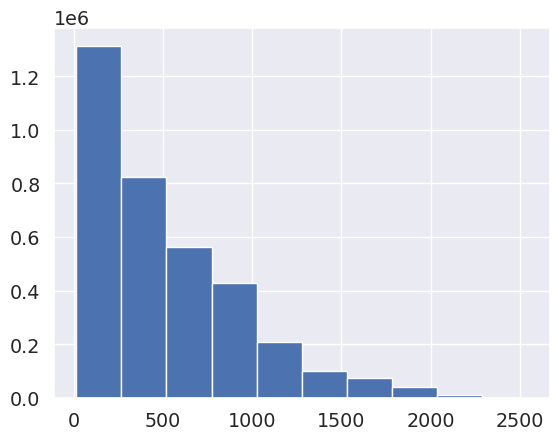

In [111]:
plt.hist(pred_grid_X4['Pred_usable_conns2'])
plt.show()

In [112]:
pred_grid_X4.sort_values(by='Pred_usable_conns2', ascending=False, inplace = True)

In [113]:
pred_grid_X4.head()

,PC1,PC2,PC3,PC4,Pred_usable_conns2,Lower,Upper,Pred_usable_conns_Err
532895,-32.990411,47.406192,-26.099726,-5.165223,2541.346,2237.18785,2864.9825,828.89301
2908457,-32.998591,47.411398,-26.095175,-5.164421,2541.346,2237.18785,2864.9825,828.89301
2908450,-32.998890,47.411189,-26.095309,-5.164284,2541.346,2237.18785,2864.9825,828.89301
2908452,-32.998805,47.411249,-26.095271,-5.164323,2541.346,2237.18785,2864.9825,828.89301
2908451,-32.998848,47.411219,-26.095290,-5.164304,2541.346,2237.18785,2864.9825,828.89301
